# 02 — Combine Tracking EDA

**Purpose**: Explore the 10 Hz Combine tracking data in depth.
Understand speed, acceleration, direction, and movement trajectories by drill type.
Extract the movement feature library.

**Output**:
- `outputs/figures/` — all visualization figures
- `data/processed/combine_features.parquet` — per-attempt movement features
- `data/processed/player_master.parquet` — master player table

> **Reminder**: This is exploratory. Conclusions are hypotheses, not facts yet.

In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ensure_dirs, FIGURES_DIR, DATA_PROCESSED, COMBINE_FEATURES_PARQUET
from src.data_loading import load_players, load_combine_results, load_combine_tracking
from src.player_mapping import assign_position_groups, build_master_player_table
from src.combine_features import (
    extract_features_from_tracking, aggregate_player_features, sort_attempt
)
from src.visualization import (
    plot_drill_player_counts, plot_drill_duration_distribution,
    plot_speed_distribution_by_drill, plot_acceleration_distribution,
    plot_movement_trajectory, plot_trajectories_comparison,
    plot_position_group_profiles, plot_missing_data_heatmap,
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(name)s | %(message)s')
ensure_dirs()
print('Setup complete. Ready to explore combine tracking data.')

Setup complete. Ready to explore combine tracking data.


## 1. Load Data

In [2]:
players = load_players()
combine_results = load_combine_results(cols=None)  # all columns
tracking = load_combine_tracking()

# Assign position groups
players = assign_position_groups(players)

print(f'Players: {len(players):,}')
print(f'Combine tracking rows: {len(tracking):,}')
print(f'Position groups: {players["position_group"].value_counts().to_dict()}')

INFO | src.data_loading | Loaded players: 510 rows × 10 cols | 0.1 MB | source: players.csv
WARNING | src.data_loading | players — columns with missing values:
draft_round                127
draft_pick_within_round    127
draft_overall_pick         127
WARNING | src.data_loading | combine_results: requested columns not in file (skipped): ['position']
INFO | src.data_loading | Loaded combine_results: 510 rows × 11 cols | 0.0 MB | source: combine_results.csv
WARNING | src.data_loading | combine_results — columns with missing values:
ten_yd_split                     85
forty                            86
vertical                         72
broad_jump                       87
three_cone                      330
short_shuttle                   309
bench_reps                      318
ngs_college_production_score      1
ngs_final_score                   1
INFO | src.data_loading | Loaded combine_tracking: 463,189 rows × 12 cols | 69.0 MB | source: combine_tracking.csv
INFO | src.data_loading 

Players: 510
Combine tracking rows: 463,189
Position groups: {'OL': 121, 'WR': 106, 'Edge': 66, 'CB': 60, 'S': 53, 'DT': 52, 'TE': 42, 'DB': 5, 'LB': 3, 'RB': 2}


## 2. Drill Overview

### 2a. Player counts per drill

INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\drill_player_counts.png


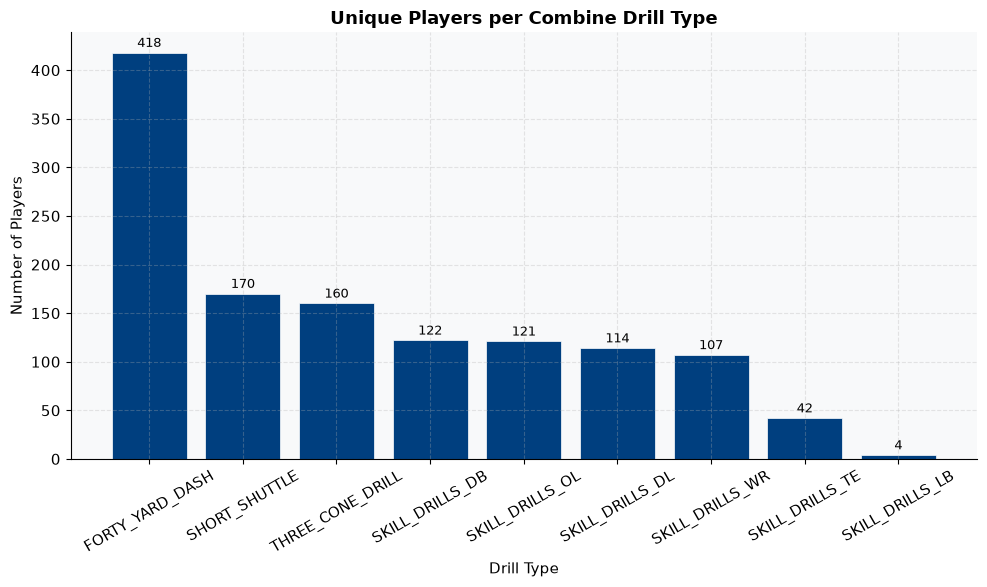

,n_players,n_rows
drill_type,,
FORTY_YARD_DASH,418,41500
SHORT_SHUTTLE,170,11690
THREE_CONE_DRILL,160,15951
SKILL_DRILLS_DB,122,94623
SKILL_DRILLS_OL,121,61129
SKILL_DRILLS_DL,114,77428
SKILL_DRILLS_WR,107,120383
SKILL_DRILLS_TE,42,37222
SKILL_DRILLS_LB,4,3263


In [3]:
# How many players participated in each drill?
fig = plot_drill_player_counts(tracking)
plt.show()

if 'drill_type' in tracking.columns:
    drill_summary = tracking.groupby('drill_type').agg(
        n_players=('nfl_id', 'nunique'),
        n_rows=('nfl_id', 'count'),
    ).sort_values('n_players', ascending=False)
    display(drill_summary)

### 2b. Drill duration distributions

INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\drill_duration_dist.png


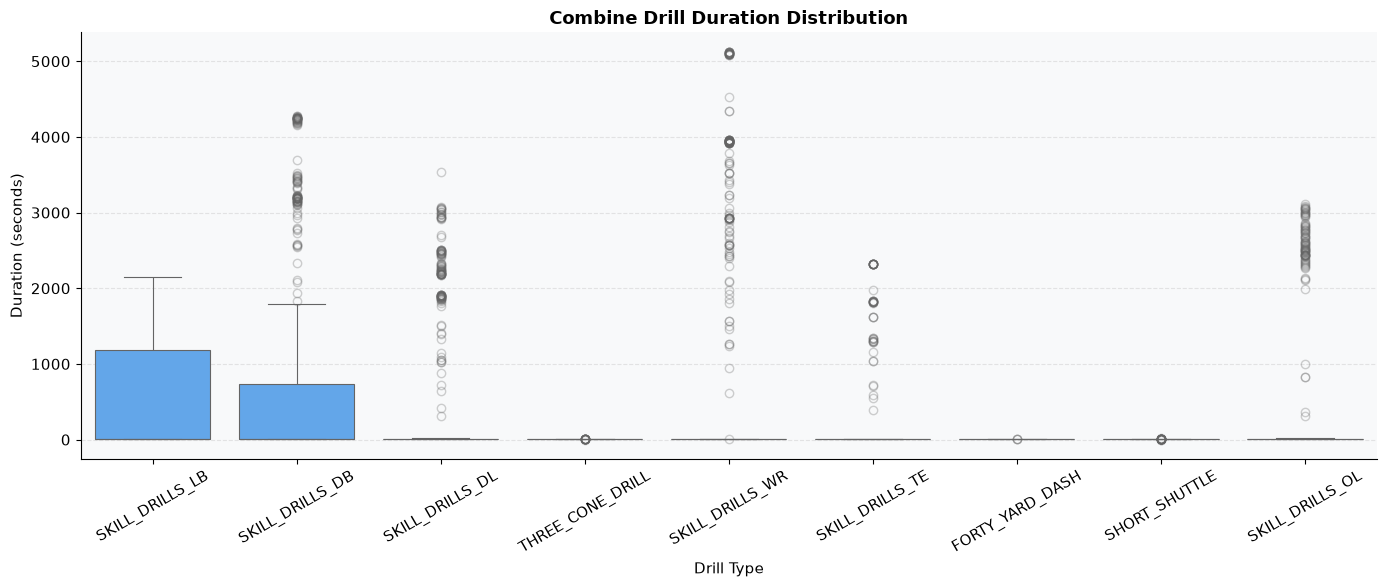

In [4]:
fig = plot_drill_duration_distribution(tracking)
plt.show()

## 3. Speed Distributions

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\visualization.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\speed_dist_by_drill.png


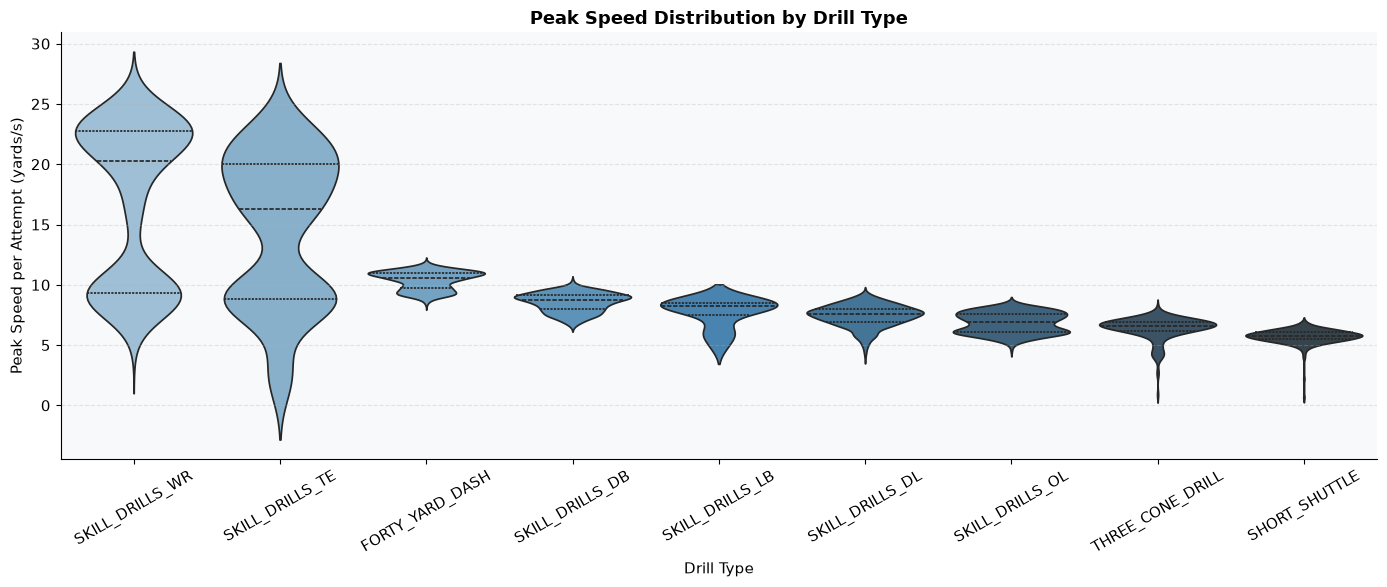

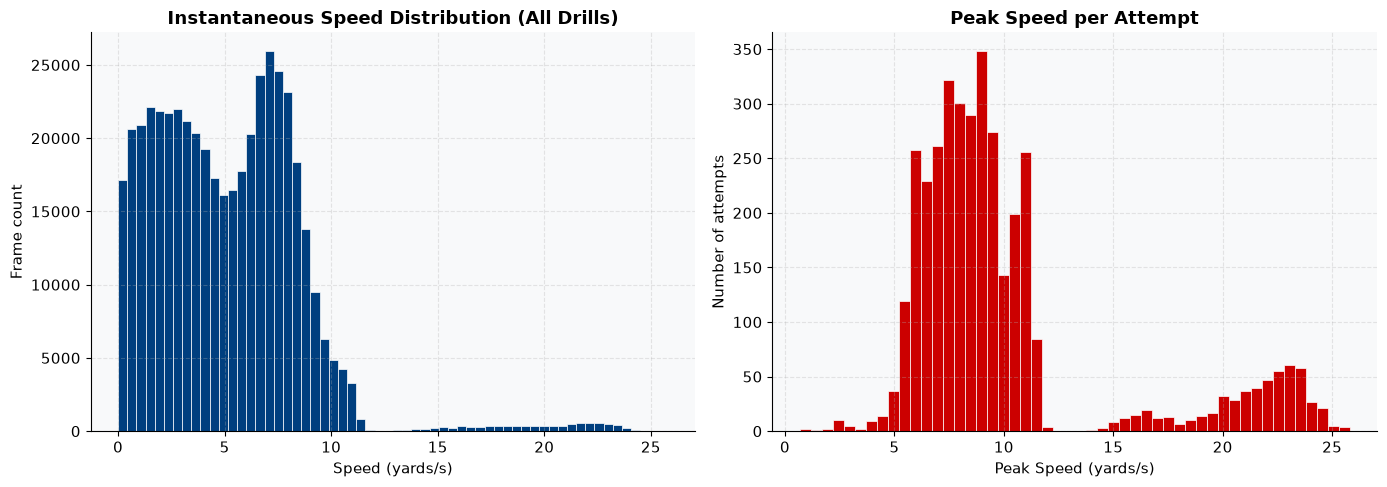

In [5]:
if 's' in tracking.columns:
    fig = plot_speed_distribution_by_drill(tracking, max_speed_only=True)
    plt.show()

    # Overall speed distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(tracking['s'].dropna(), bins=60, color='#003f7f', edgecolor='white', linewidth=0.5)
    axes[0].set_title('Instantaneous Speed Distribution (All Drills)', fontweight='bold')
    axes[0].set_xlabel('Speed (yards/s)')
    axes[0].set_ylabel('Frame count')

    # Max speed per attempt
    keys = [c for c in ['nfl_id', 'drill_type', 'attempt'] if c in tracking.columns]
    max_speed_per_attempt = tracking.groupby(keys)['s'].max().reset_index(name='max_speed')
    axes[1].hist(max_speed_per_attempt['max_speed'].dropna(), bins=50, color='#cc0000', edgecolor='white', linewidth=0.5)
    axes[1].set_title('Peak Speed per Attempt', fontweight='bold')
    axes[1].set_xlabel('Peak Speed (yards/s)')
    axes[1].set_ylabel('Number of attempts')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'speed_overall_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Speed column (s) not found in tracking data.')

## 4. Acceleration Distributions

**Research question**: Do high-acceleration athletes at the Combine become better NFL performers?
First we need to understand the distribution.

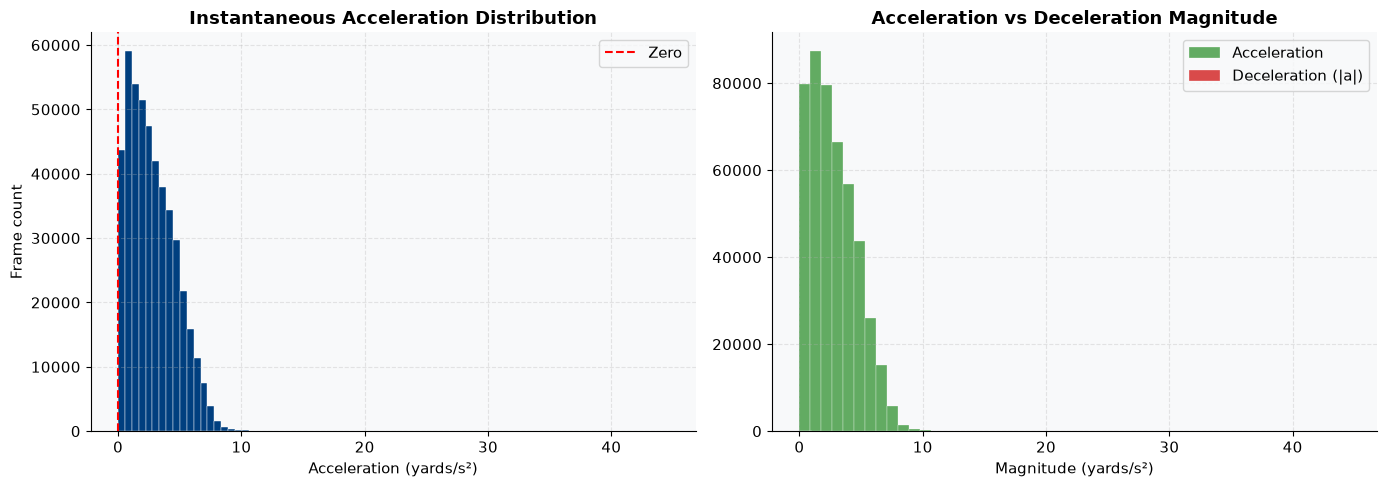

Mean acceleration: 2.813 yd/s²
Mean positive acceleration: 2.814 yd/s²
Mean deceleration: nan yd/s²
Max acceleration: 44.607 yd/s²
Max deceleration: 0.000 yd/s²


In [6]:
if 'a' in tracking.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    acc_vals = tracking['a'].dropna()
    axes[0].hist(acc_vals, bins=80, color='#003f7f', edgecolor='white', linewidth=0.3)
    axes[0].set_title('Instantaneous Acceleration Distribution', fontweight='bold')
    axes[0].set_xlabel('Acceleration (yards/s²)')
    axes[0].set_ylabel('Frame count')
    axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
    axes[0].legend()

    # Positive vs negative acceleration
    pos_acc = acc_vals[acc_vals > 0]
    neg_acc = acc_vals[acc_vals < 0]
    axes[1].hist(pos_acc, bins=50, color='#228B22', alpha=0.7, edgecolor='white', label='Acceleration', linewidth=0.3)
    axes[1].hist(neg_acc.abs(), bins=50, color='#cc0000', alpha=0.7, edgecolor='white', label='Deceleration (|a|)', linewidth=0.3)
    axes[1].set_title('Acceleration vs Deceleration Magnitude', fontweight='bold')
    axes[1].set_xlabel('Magnitude (yards/s²)')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'acceleration_overall_dist.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Mean acceleration: {acc_vals.mean():.3f} yd/s²')
    print(f'Mean positive acceleration: {pos_acc.mean():.3f} yd/s²')
    print(f'Mean deceleration: {neg_acc.mean():.3f} yd/s²')
    print(f'Max acceleration: {acc_vals.max():.3f} yd/s²')
    print(f'Max deceleration: {acc_vals.min():.3f} yd/s²')
else:
    print('Acceleration column (a) not found — will derive from speed.')

## 5. Direction Distribution

Direction should vary widely in multi-directional drills (3-cone, shuttle)
and be nearly uniform in straight-line drills (40-yard dash).

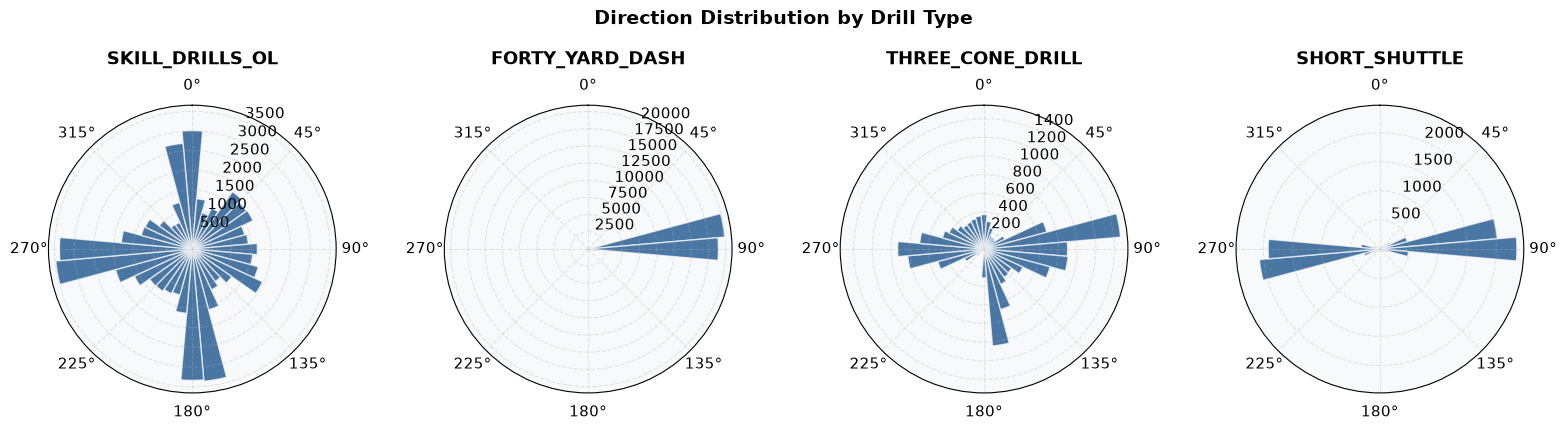

In [7]:
if 'dir' in tracking.columns and 'drill_type' in tracking.columns:
    drill_types = tracking['drill_type'].dropna().unique()
    n_drills = len(drill_types)
    fig, axes = plt.subplots(1, min(n_drills, 4), figsize=(4 * min(n_drills, 4), 4),
                             subplot_kw=dict(polar=True))
    if n_drills == 1:
        axes = [axes]

    for ax, drill in zip(axes, drill_types[:4]):
        subset = tracking[tracking['drill_type'] == drill]['dir'].dropna()
        if len(subset) == 0:
            continue
        # Polar histogram
        bins = np.linspace(0, 2 * np.pi, 37)
        radians = np.deg2rad(subset)
        counts, _ = np.histogram(radians, bins=bins)
        width = (2 * np.pi) / 36
        bars = ax.bar(bins[:-1], counts, width=width, color='#003f7f', alpha=0.7, edgecolor='white')
        ax.set_title(drill, fontweight='bold', pad=10)
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)

    fig.suptitle('Direction Distribution by Drill Type', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'direction_polar_by_drill.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('dir or drill_type column missing.')

## 6. Example Movement Trajectories

Visualize 3-5 example trajectories for different drills, colored by speed.
This gives intuition for what the tracking data looks like and helps us understand
what features are feasible to extract.

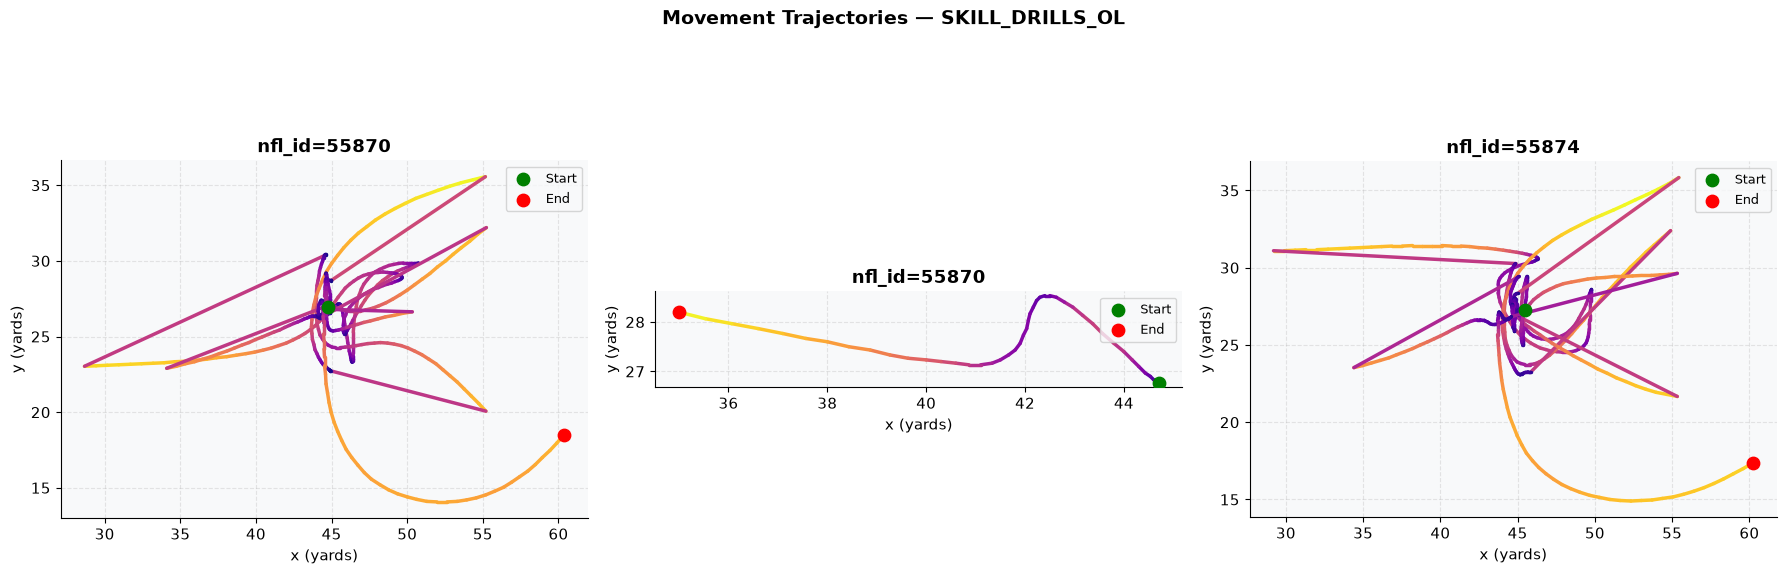

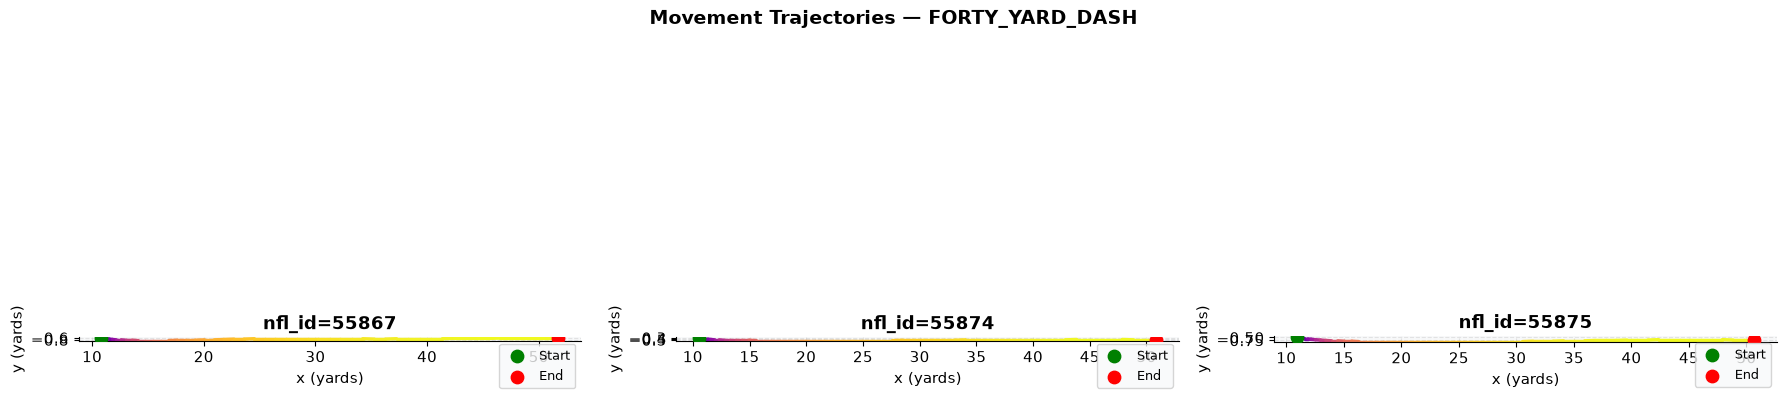

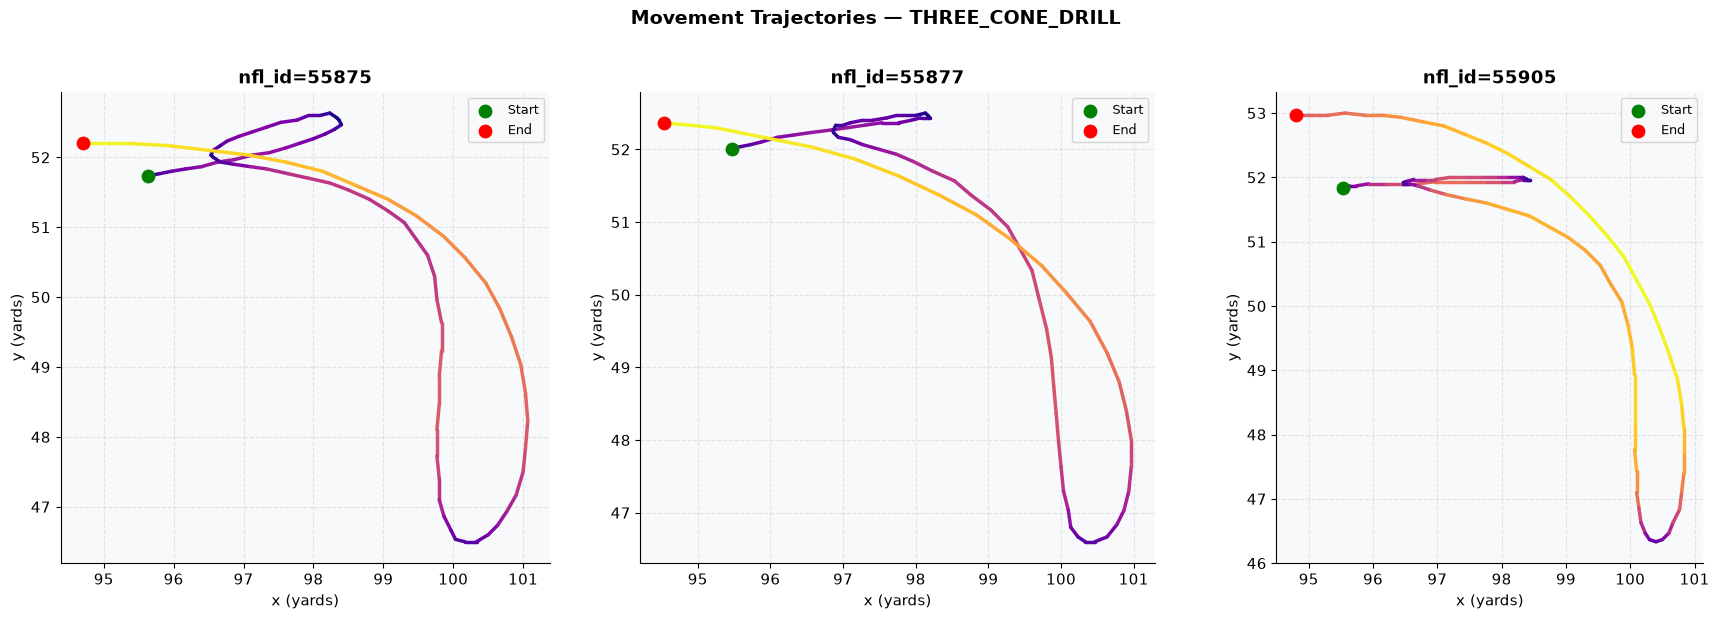

In [8]:
if 'drill_type' in tracking.columns and 'x' in tracking.columns:
    drill_types = tracking['drill_type'].dropna().unique()

    for drill in drill_types[:3]:  # Plot 3 drill types
        drill_data = tracking[tracking['drill_type'] == drill]
        if len(drill_data) == 0:
            continue

        # Pick first 3 unique players with enough frames
        group_keys = [c for c in ['nfl_id', 'attempt'] if c in drill_data.columns]
        sample_attempts = (
            drill_data.groupby(group_keys)
            .size()
            .reset_index(name='n_frames')
            .query('n_frames >= 10')
            .head(3)
        )

        if len(sample_attempts) == 0:
            continue

        fig, axes = plt.subplots(1, len(sample_attempts), figsize=(6 * len(sample_attempts), 6))
        if len(sample_attempts) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, sample_attempts.iterrows()):
            mask = drill_data['nfl_id'] == row['nfl_id']
            if 'attempt' in drill_data.columns:
                mask &= drill_data['attempt'] == row['attempt']
            attempt_df = sort_attempt(drill_data[mask])
            if len(attempt_df) < 3:
                continue
            title = f'nfl_id={row["nfl_id"]}'
            plot_movement_trajectory(attempt_df, color_by='s', title=title, ax=ax)

        fig.suptitle(f'Movement Trajectories — {drill}', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        fname = f'trajectory_examples_{drill.replace(" ", "_").replace("/", "_")}.png'
        plt.savefig(FIGURES_DIR / fname, dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('Cannot plot trajectories: missing x/y or drill_type columns.')

## 7. Extract Movement Features

This is the core computation. For every (player, drill, attempt) triple,
compute all movement features.

**This may take a few minutes for large tracking files.**

In [9]:
print('Extracting movement features from combine tracking...')
print(f'Total attempts to process: check above')

features_df = extract_features_from_tracking(tracking, verbose=True)

print(f'\nFeatures extracted: {features_df.shape}')
print(f'Columns: {features_df.columns.tolist()}')
display(features_df.head())

# Check for NaN-heavy columns
nan_pct = (features_df.isnull().sum() / len(features_df) * 100).sort_values(ascending=False)
print('\nFeature columns with >10% NaN:')
display(nan_pct[nan_pct > 10].to_frame('nan_pct'))

Extracting movement features from combine tracking...
Total attempts to process: check above


INFO | src.combine_features | Extracting features from 3,717 attempts ...
INFO | src.combine_features |   500/3717 attempts | 107 unique players
INFO | src.combine_features |   1000/3717 attempts | 216 unique players
INFO | src.combine_features |   1500/3717 attempts | 328 unique players
INFO | src.combine_features |   2000/3717 attempts | 375 unique players
INFO | src.combine_features |   2500/3717 attempts | 415 unique players
INFO | src.combine_features |   3000/3717 attempts | 455 unique players
INFO | src.combine_features |   3500/3717 attempts | 494 unique players
INFO | src.combine_features | Feature extraction complete: 3717 attempts | 510 unique players | 52 features



Features extracted: (3717, 52)
Columns: ['nfl_id', 'drill_type', 'attempt', 'mean_speed', 'median_speed', 'max_speed', 'speed_std', 'time_to_peak_speed', 'speed_at_5s', 'speed_at_10s', 'pct_time_above_80pct_peak', 'mean_acceleration', 'max_acceleration', 'min_acceleration', 'acceleration_std', 'first_step_acceleration', 'mean_positive_acceleration', 'mean_deceleration', 'max_deceleration', 'pct_time_accelerating', 'pct_time_decelerating', 'total_direction_change', 'max_direction_change', 'mean_direction_change_per_frame', 'direction_change_rate', 'n_direction_events', 'circular_mean_direction', 'circular_std_direction', 'movement_efficiency', 'total_path_length', 'straight_line_distance', 'displacement_x', 'displacement_y', 'n_cut_sequences', 'best_brake_duration', 'best_brake_magnitude', 'best_speed_at_brake_end', 'best_dir_change_during_brake', 'best_transition_time', 'best_reaccel_magnitude', 'best_peak_reaccel', 'best_total_sequence_time', 'mean_peak_reaccel', 'mean_brake_magnitud

,nfl_id,drill_type,attempt,mean_speed,median_speed,max_speed,speed_std,time_to_peak_speed,speed_at_5s,speed_at_10s,...,mean_peak_reaccel,mean_brake_magnitude,mean_transition_time,time_to_50pct_peak,time_to_75pct_peak,time_to_90pct_peak,burst_impulse_0_5s,burst_impulse_0_1s,n_frames,duration_s
0,55867,FORTY_YARD_DASH,2,7.966603,9.435000,10.416667,3.005433,4.6,10.383333,NaN,...,NaN,NaN,NaN,1.0,1.7,2.5,1.906638,0.269231,52,5.2
1,55867,SKILL_DRILLS_LB,1,4.276208,4.223333,8.630000,2.216070,39.6,0.403333,5.133333,...,NaN,NaN,NaN,3.7,11.3,23.1,0.962762,0.136400,581,58.1
2,55867,SKILL_DRILLS_LB,2,5.290437,5.526667,8.523334,2.586276,14.4,8.443334,6.803333,...,NaN,NaN,NaN,1.6,3.4,3.9,0.214144,0.012229,145,14.5
3,55867,SKILL_DRILLS_LB,4,4.189718,4.326667,6.343333,1.545305,7.0,3.450000,NaN,...,NaN,NaN,NaN,0.7,3.0,5.6,1.870977,0.299602,71,7.1
4,55870,SKILL_DRILLS_OL,1,3.179477,3.003333,8.213333,2.247464,26.9,3.976667,2.803333,...,NaN,NaN,NaN,4.6,15.0,15.9,0.511684,0.156142,510,51.0



Feature columns with >10% NaN:


,nan_pct
best_peak_reaccel,100.000000
best_brake_duration,100.000000
n_cut_sequences,100.000000
best_brake_magnitude,100.000000
mean_transition_time,100.000000
best_dir_change_during_brake,100.000000
best_transition_time,100.000000
best_reaccel_magnitude,100.000000
best_speed_at_brake_end,100.000000
best_total_sequence_time,100.000000


In [10]:
# Save to Parquet for downstream notebooks
features_df.to_parquet(COMBINE_FEATURES_PARQUET, index=False)
print(f'Saved: {COMBINE_FEATURES_PARQUET}')

# Also create per-player aggregated features (best attempt per drill)
player_features = aggregate_player_features(features_df, agg_strategy='best_attempt')
print(f'Player-level features: {player_features.shape}')
display(player_features.head())

INFO | src.combine_features | aggregate_player_features (best_attempt): 1258 rows


Saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\data\processed\combine_features.parquet
Player-level features: (1258, 52)


,nfl_id,drill_type,attempt,mean_speed,median_speed,max_speed,speed_std,time_to_peak_speed,speed_at_5s,speed_at_10s,...,mean_peak_reaccel,mean_brake_magnitude,mean_transition_time,time_to_50pct_peak,time_to_75pct_peak,time_to_90pct_peak,burst_impulse_0_5s,burst_impulse_0_1s,n_frames,duration_s
0,55867,FORTY_YARD_DASH,2,7.966603,9.435000,10.416667,3.005433,4.6,10.383333,NaN,...,NaN,NaN,NaN,1.0,1.7,2.5,1.906638,0.269231,52,5.2
1,55867,SKILL_DRILLS_LB,1,4.276208,4.223333,8.630000,2.216070,39.6,0.403333,5.133333,...,NaN,NaN,NaN,3.7,11.3,23.1,0.962762,0.136400,581,58.1
2,55870,SKILL_DRILLS_OL,1,3.179477,3.003333,8.213333,2.247464,26.9,3.976667,2.803333,...,NaN,NaN,NaN,4.6,15.0,15.9,0.511684,0.156142,510,51.0
3,55874,FORTY_YARD_DASH,1,7.554877,8.751667,10.073334,2.778123,4.8,10.043333,NaN,...,NaN,NaN,NaN,1.0,1.9,3.1,2.104229,0.325872,54,5.4
4,55874,SKILL_DRILLS_OL,1,2.948993,2.380000,7.876667,2.277161,24.4,1.286667,2.520000,...,NaN,NaN,NaN,11.7,12.3,23.7,1.088388,0.105935,553,55.3


## 8. Feature Distributions by Drill

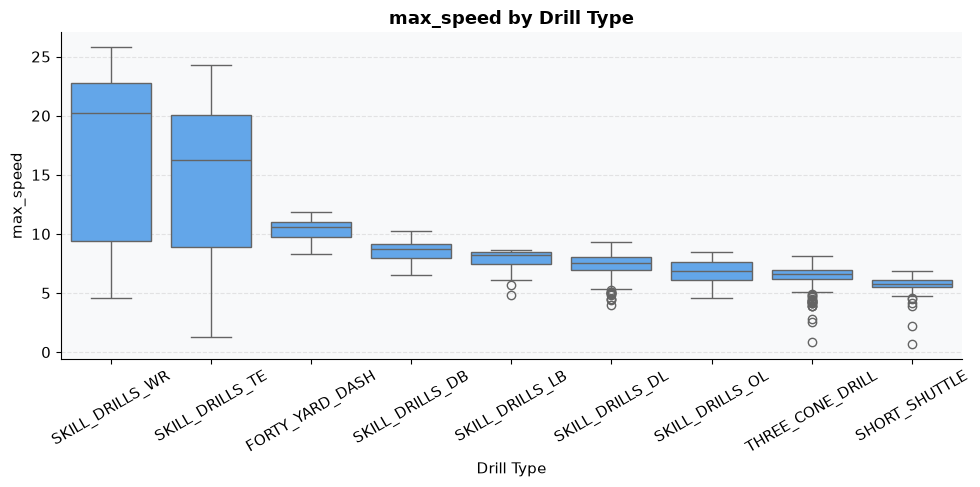

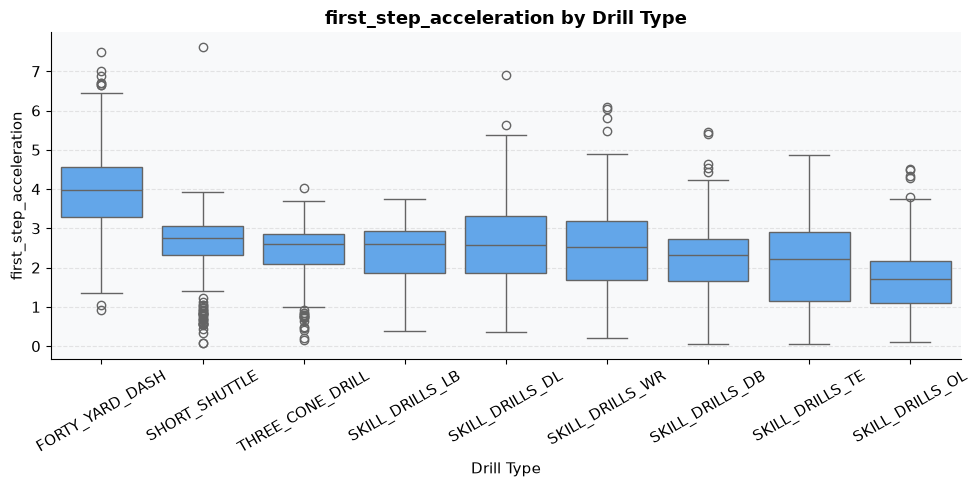

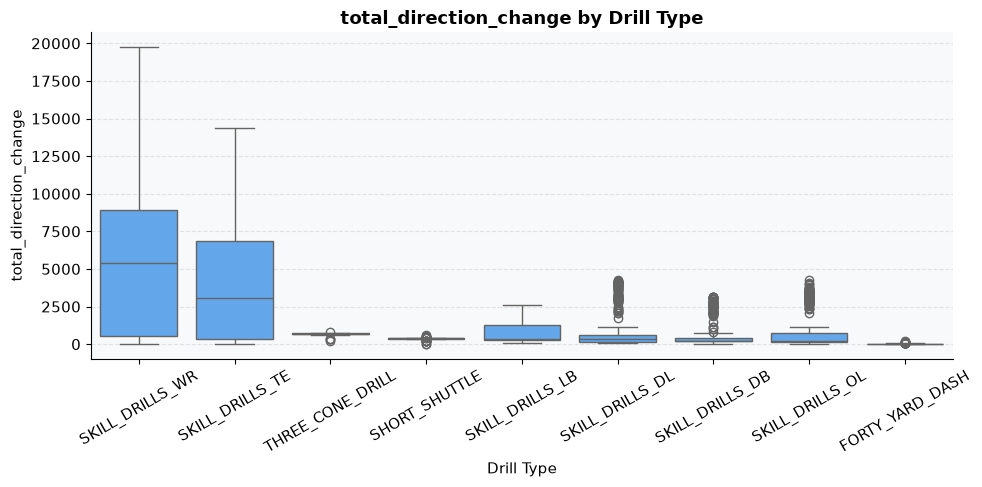

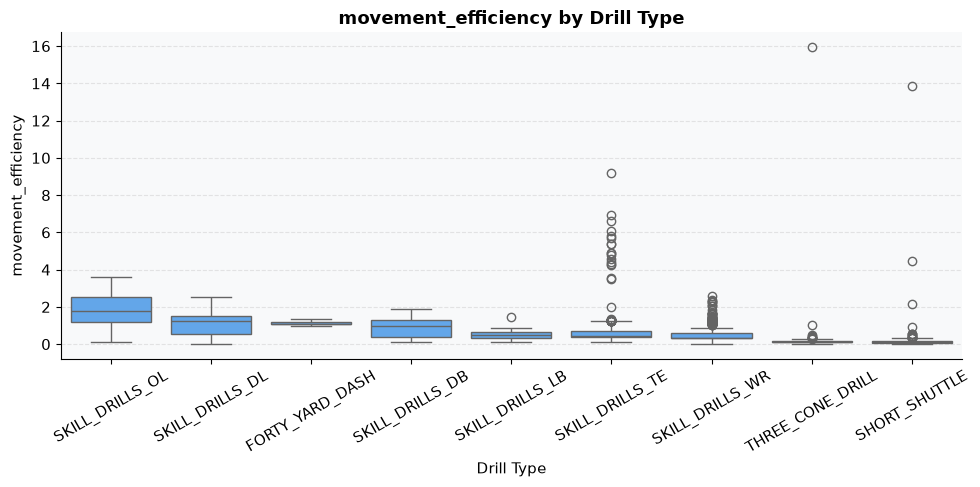

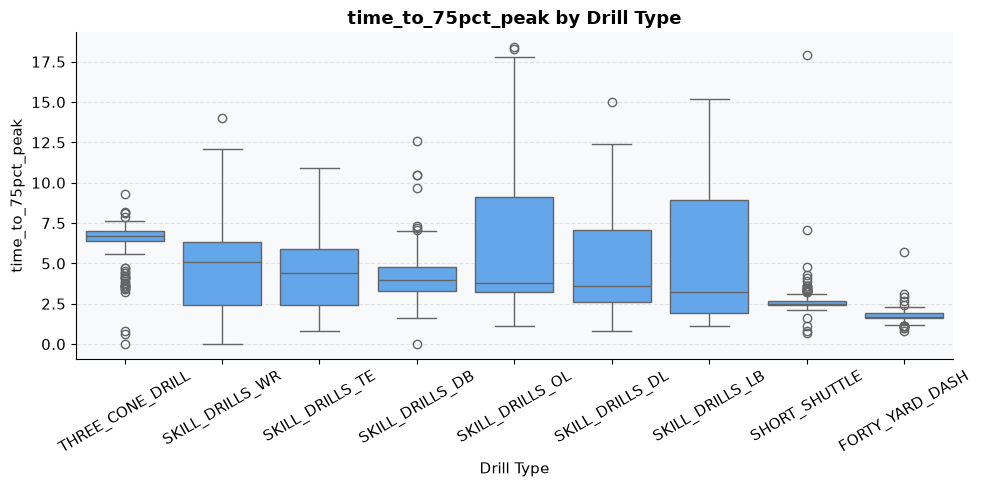

In [11]:
# Visualize key feature distributions
key_features = [
    'max_speed', 'first_step_acceleration', 'total_direction_change',
    'movement_efficiency', 'best_peak_reaccel', 'time_to_75pct_peak',
]
key_features = [f for f in key_features if f in features_df.columns]

if 'drill_type' in features_df.columns:
    for feat in key_features:
        valid = features_df[['drill_type', feat]].dropna()
        if len(valid) < 10:
            continue
        order = valid.groupby('drill_type')[feat].median().sort_values(ascending=False).index
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=valid, x='drill_type', y=feat, order=order, color='#4da6ff', ax=ax)
        ax.set_title(f'{feat} by Drill Type', fontweight='bold')
        ax.set_xlabel('Drill Type')
        ax.set_ylabel(feat)
        ax.tick_params(axis='x', rotation=30)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'feature_{feat}_by_drill.png', dpi=150, bbox_inches='tight')
        plt.show()

## 9. Compare Tracking Features vs Traditional Combine Metrics

**Research question**: Which tracking features provide information not captured by traditional metrics?

e.g., Do two players with the same 40-yard time have different acceleration profiles?

In [12]:
from src.statistics import correlation_matrix, build_correlation_summary
from src.visualization import plot_correlation_heatmap, plot_combine_vs_nfl
from src.config import TRADITIONAL_COMBINE_COLS

# Build master player table
from src.player_mapping import build_master_player_table
master = build_master_player_table(players, combine_results=combine_results)

# Join with player-level tracking features (best attempt per drill)
# Pivot to wide format: one row per player
if 'drill_type' in player_features.columns:
    # Pivot: drill_type becomes column prefixes
    feat_cols = [c for c in player_features.columns if c not in ['nfl_id', 'drill_type', 'attempt']]
    player_feat_wide = player_features.pivot_table(
        index='nfl_id', columns='drill_type', values=feat_cols, aggfunc='first'
    )
    player_feat_wide.columns = ['_'.join(map(str, c)).strip() for c in player_feat_wide.columns]
    player_feat_wide = player_feat_wide.reset_index()
    
    master_features = master.merge(player_feat_wide, on='nfl_id', how='left')
    print(f'Master + features: {master_features.shape}')
else:
    master_features = master.merge(player_features.drop(columns=['attempt'], errors='ignore'), on='nfl_id', how='left')
    print(f'Master + features (no drill pivot): {master_features.shape}')

INFO | src.player_mapping | Master: merged combine_results — 510 rows, 21 columns
INFO | src.player_mapping | build_master_player_table complete: 510 players | 21 columns


Master + features: (510, 353)


Traditional metrics available: ['ten_yd_split', 'forty', 'vertical', 'broad_jump', 'three_cone', 'short_shuttle', 'ngs_athleticism_score']
Tracking features available: 63

Tracking vs Traditional — Spearman correlation matrix:


,ten_yd_split,forty,vertical,broad_jump,three_cone,short_shuttle,ngs_athleticism_score
first_step_acceleration_FORTY_YARD_DASH,-0.070020,-0.064026,0.085999,0.114062,-0.183621,-0.106946,0.047591
first_step_acceleration_SHORT_SHUTTLE,-0.018835,-0.044515,-0.036358,-0.060347,0.017061,0.000469,0.032355
first_step_acceleration_SKILL_DRILLS_DB,0.024339,0.029919,-0.043686,-0.097476,0.081263,0.071894,-0.036150
first_step_acceleration_SKILL_DRILLS_DL,0.069648,0.113832,-0.037342,-0.124158,-0.013522,-0.004480,0.013186
first_step_acceleration_SKILL_DRILLS_LB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_step_acceleration_SKILL_DRILLS_OL,0.062907,0.186197,0.002790,-0.086032,-0.105437,-0.093009,-0.037811
first_step_acceleration_SKILL_DRILLS_TE,0.086223,-0.182166,-0.014059,-0.045458,-0.281879,-0.330819,-0.032956
first_step_acceleration_SKILL_DRILLS_WR,-0.123870,0.133194,-0.266345,-0.083500,-0.018567,0.109571,-0.190112
first_step_acceleration_THREE_CONE_DRILL,0.183037,0.074813,-0.118060,-0.114770,0.217633,0.239728,-0.103218
max_acceleration_FORTY_YARD_DASH,-0.525653,-0.535414,0.484390,0.550178,-0.614418,-0.566719,0.110931


INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\corr_tracking_vs_traditional.png


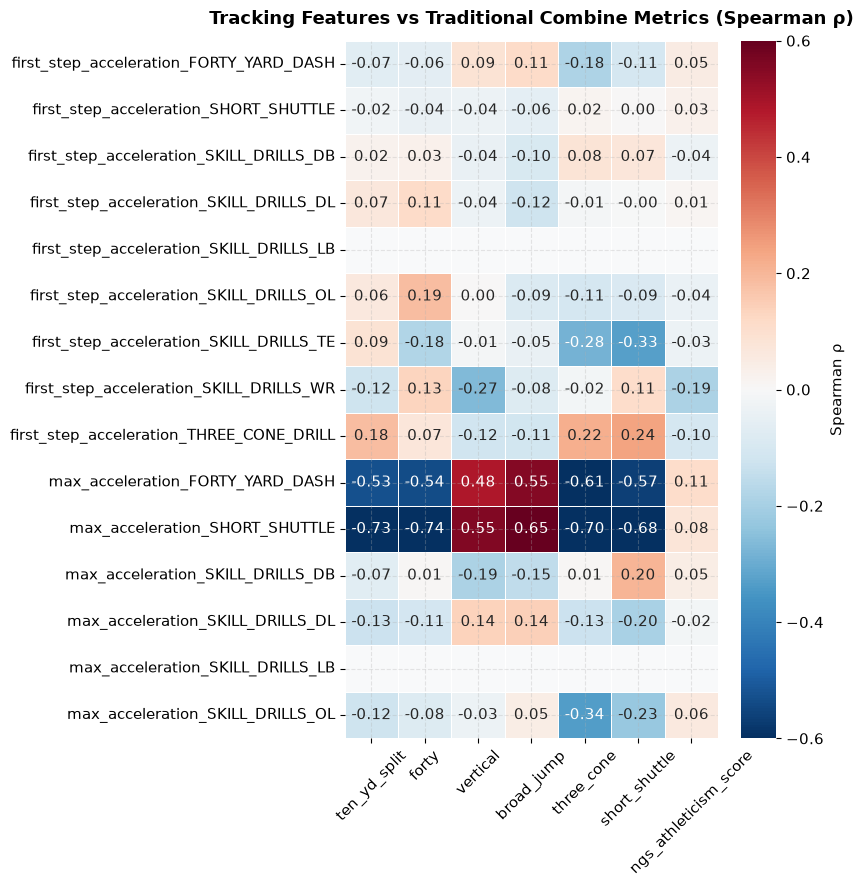

In [13]:
# Correlation: tracking features vs traditional combine metrics
traditional_metrics = [
    c for c in ['ten_yd_split', 'forty', 'vertical', 'broad_jump', 
                 'three_cone', 'short_shuttle', 'ngs_athleticism_score']
    if c in master_features.columns
]

tracking_feats = [
    c for c in master_features.columns
    if any(c.startswith(f) for f in [
        'max_speed', 'first_step_acceleration', 'total_direction_change',
        'movement_efficiency', 'best_peak_reaccel', 'mean_speed',
        'max_acceleration', 'time_to_75pct_peak',
    ])
]

print(f'Traditional metrics available: {traditional_metrics}')
print(f'Tracking features available: {len(tracking_feats)}')

if traditional_metrics and tracking_feats:
    corr_mat = correlation_matrix(
        master_features,
        x_cols=tracking_feats[:15],  # limit for readability
        y_cols=traditional_metrics,
        method='spearman',
    )
    print('\nTracking vs Traditional — Spearman correlation matrix:')
    display(corr_mat)

    if not corr_mat.empty:
        plot_correlation_heatmap(
            corr_mat,
            title='Tracking Features vs Traditional Combine Metrics (Spearman ρ)',
            filename='corr_tracking_vs_traditional.png',
        )
        plt.show()
else:
    print('NOT YET COMPUTED — insufficient columns available for this analysis.')

## 10. Position Group Movement Profiles

Do different position groups move fundamentally differently at the Combine?
This helps us understand which positions are most worth investigating.

Sample sizes per position group:


,count
position_group,
OL,318
WR,252
Edge,166
CB,140
DT,128
S,119
TE,114
DB,8
LB,7


INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\position_profiles.png


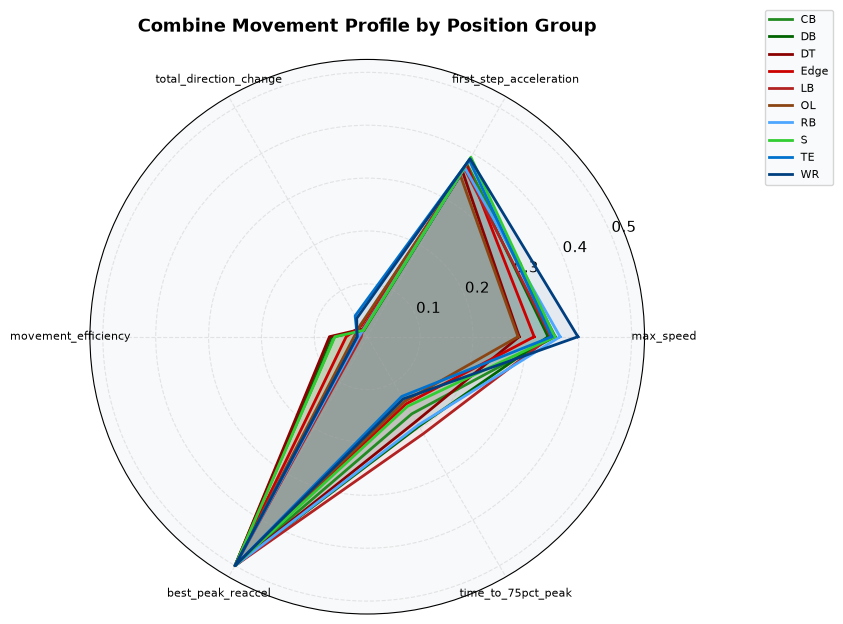


--- max_speed by position group ---


,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
CB,140,9.449510,9.609692,1.703262,9.090833,10.974167,5.756667,11.854232
DT,128,7.931800,7.898901,1.392060,6.966667,9.144166,5.106667,11.060000
Edge,166,8.507076,8.607943,1.680667,6.911667,10.242500,5.063334,11.453333
OL,318,7.671419,7.843333,1.552091,6.364763,9.092952,0.678458,10.286469
S,119,9.508618,9.576667,1.528011,9.095000,10.810000,5.662851,11.503472
TE,114,10.511910,9.445000,5.255839,6.873744,10.579167,3.892019,24.249016
WR,252,11.804027,10.686666,5.553029,9.807500,11.305000,4.282610,25.794157



--- first_step_acceleration by position group ---


,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
CB,140,3.122646,2.918638,1.188366,2.460831,3.589330,0.075441,7.614422
DT,128,2.893134,2.794319,1.035685,2.262609,3.422537,0.503598,5.512613
Edge,166,2.923008,2.911051,1.178328,2.032246,3.800770,0.351402,5.900672
OL,318,2.588186,2.731645,1.206181,1.722757,3.280512,0.103077,7.480193
S,119,3.372552,3.031864,1.092068,2.578061,4.198796,1.336619,6.693662
TE,114,2.888581,2.983645,1.220433,2.231426,3.663476,0.086803,5.131035
WR,252,3.026552,3.007586,1.108388,2.393964,3.741458,0.150017,6.194782



--- total_direction_change by position group ---


...

,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
CB,140,0.703676,0.988690,0.480187,0.174594,1.057455,0.022654,2.167884
DT,128,0.803149,1.141281,0.591211,0.204097,1.251802,0.051479,1.663590
Edge,166,0.686278,0.637096,0.529701,0.177957,1.121334,0.017681,1.536122
OL,318,0.791474,0.399512,1.270315,0.172346,1.225154,0.031086,15.941625
S,119,0.714050,0.978637,0.429864,0.241361,1.067849,0.028069,1.588646
TE,114,0.484628,0.303799,0.419419,0.140183,1.075264,0.042604,1.142053
WR,252,0.510484,0.306961,0.431331,0.134983,1.044084,0.003041,1.100389



--- best_peak_reaccel by position group ---


""



--- time_to_75pct_peak by position group ---


,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
CB,140,3.359286,3.1,2.036250,1.875,4.025,0.7,17.9
DT,128,3.796094,3.4,2.339877,1.900,4.275,1.3,11.3
Edge,166,4.187349,2.7,3.043188,1.900,6.500,1.3,15.2
OL,318,6.081447,2.6,5.351541,1.900,11.525,0.0,18.4
S,119,3.196639,2.8,1.755859,1.700,4.150,1.0,10.5
TE,114,3.325439,2.4,1.894884,1.800,4.775,1.3,7.6
WR,252,3.957143,2.5,2.601821,1.900,6.025,1.1,11.0


In [14]:
# Join position info onto player_features
pos_map = players[['nfl_id', 'position_group']].drop_duplicates()
feat_with_pos = player_features.merge(pos_map, on='nfl_id', how='left')

profile_feats = [f for f in [
    'max_speed', 'first_step_acceleration', 'total_direction_change',
    'movement_efficiency', 'best_peak_reaccel', 'time_to_75pct_peak',
] if f in feat_with_pos.columns]

if 'position_group' in feat_with_pos.columns and profile_feats:
    print('Sample sizes per position group:')
    display(feat_with_pos['position_group'].value_counts().to_frame())

    plot_position_group_profiles(
        feat_with_pos,
        feature_cols=profile_feats,
        position_col='position_group',
    )
    plt.show()

    # Summary stats by position group
    from src.statistics import compare_groups
    for feat in profile_feats:
        print(f'\n--- {feat} by position group ---')
        display(compare_groups(feat_with_pos, 'position_group', feat))
else:
    print('Position group or feature columns not available.')